In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
athlete=pd.read_csv("athlete_events.csv")
region=pd.read_csv("noc_regions.csv")

In [3]:
athlete.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


# Missing value

In [4]:
athlete.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

# Merging data

In [5]:
df = athlete.merge(region, on="NOC", how="left")

In [6]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [7]:
df.to_csv("olym_clean.csv", index=False)

In [8]:
copy= athlete.copy()

In [9]:
copy.duplicated().sum()

np.int64(1385)

In [10]:
copy = copy.drop_duplicates()

In [11]:
copy = copy.merge(region, on="NOC", how="left")

In [12]:
copy.isnull().sum()

ID             0
Name           0
Sex            0
Age         9315
Height     58814
Weight     61527
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     229959
region       370
notes     264696
dtype: int64

In [13]:
copy[copy['region'].isnull()][['Team', 'NOC']].drop_duplicates()

,Team,NOC
578,Singapore,SGP
6259,Refugee Olympic Athletes,ROT
44161,June Climene,SGP
60733,Unknown,UNK
64317,Tuvalu,TUV
80536,Rika II,SGP
107955,Singapore-2,SGP
234682,Singapore-1,SGP


In [14]:
copy['region'] = copy['region'].fillna('Unknown')

In [15]:
medal_copy = copy.dropna(subset=['Medal'])

In [16]:
print("Total Records :", len(copy))
print("Olympic Games :", copy['Games'].nunique())
print("Countries     :", copy['region'].nunique())
print("Sports        :", copy['Sport'].nunique())
print("Events        :", copy['Event'].nunique())
print("Athletes      :", copy['Name'].nunique())

Total Records : 269731
Olympic Games : 51
Countries     : 206
Sports        : 66
Events        : 765
Athletes      : 134732


In [17]:
medal_copy = copy.dropna(subset=['Medal'])
print("Gold   :", (medal_copy['Medal'] == 'Gold').sum())
print("Silver :", (medal_copy['Medal'] == 'Silver').sum())
print("Bronze :", (medal_copy['Medal'] == 'Bronze').sum())

Gold   : 13369
Silver : 13108
Bronze : 13295


In [18]:
copy.to_csv("olymp_clean.csv", index=False)

In [19]:
medal_copy= copy.dropna(subset=['Medal'])

In [20]:
medal_copy.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland,NaN
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland,NaN
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland,NaN
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland,NaN


In [21]:
medal_copy['Medal'].value_counts()

Medal
Gold      13369
Bronze    13295
Silver    13108
Name: count, dtype: int64

In [22]:
country_medals = medal_copy.groupby(['region', 'Medal']).size().unstack(fill_value=0)
country_medals

Medal,Bronze,Gold,Silver
region,,,
Afghanistan,2,0,0
Algeria,8,5,4
Argentina,91,91,92
Armenia,9,2,5
Australia,522,368,459
...,...,...,...
Venezuela,10,2,3
Vietnam,0,1,3
"Virgin Islands, US",0,0,1


In [23]:
country_medals['Total'] = (country_medals['Gold'] + country_medals['Silver'] +country_medals['Bronze'])

In [24]:
country_medals = country_medals.sort_values(by='Total',ascending=False)

In [25]:
country_medals.head(10)

Medal,Bronze,Gold,Silver,Total
region,,,,
USA,1358,2638,1641,5637
Russia,1178,1599,1170,3947
Germany,1260,1301,1195,3756
UK,651,677,739,2067
France,666,499,602,1767
Italy,531,575,531,1637
Sweden,535,479,522,1536
Canada,451,463,438,1352
Australia,522,368,459,1349


In [26]:
medal_copy = copy.dropna(subset=['Medal'])
tally = medal_copy.groupby(['region', 'Medal']).size().unstack(fill_value=0)
tally['Total'] = (tally['Gold'] +tally['Silver'] +tally['Bronze'])
tally = tally.sort_values(by='Total', ascending=False)
tally

Medal,Bronze,Gold,Silver,Total
region,,,,
USA,1358,2638,1641,5637
Russia,1178,1599,1170,3947
Germany,1260,1301,1195,3756
UK,651,677,739,2067
France,666,499,602,1767
...,...,...,...,...
Kosovo,0,1,0,1
Guatemala,0,0,1,1
Guyana,1,0,0,1


In [27]:
def medal_tally_year(df, year):
    medal_copy = copy.dropna(subset=['Medal'])
    medal_copy = medal_copy[medal_copy['Year'] == year]
    tally = medal_copy.groupby(['region', 'Medal']).size().unstack(fill_value=0)
    tally['Total'] = (tally['Gold'] +tally['Silver'] +tally['Bronze'])
    return tally.sort_values(by='Total',ascending=False )

In [28]:
y=int(input("Enter Year"))
medal_tally_year(copy, y).head(10)

Enter Year 2016


Medal,Bronze,Gold,Silver,Total
region,,,,
USA,71,139,54,264
Germany,67,49,43,159
UK,26,64,55,145
Russia,35,52,28,115
China,37,46,30,113
France,21,20,55,96
Australia,25,23,34,82
Italy,24,8,40,72
Canada,61,4,4,69


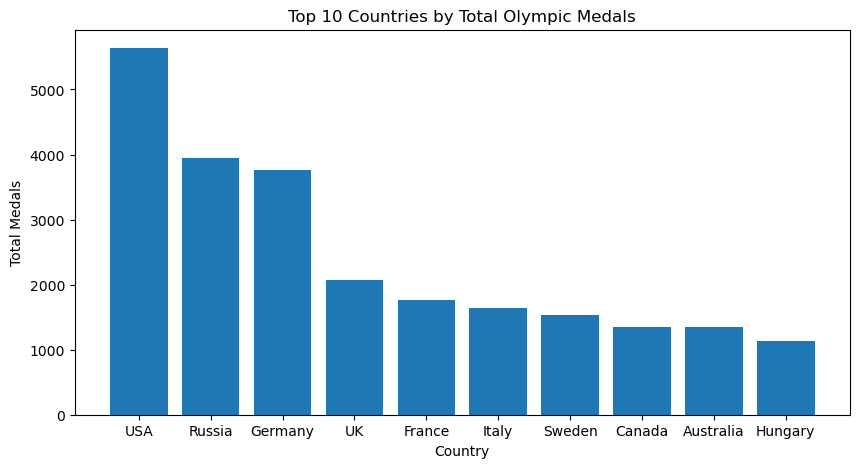

In [29]:
top10=tally.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10.index,top10["Total"])
plt.title("Top 10 Countries by Total Olympic Medals")
plt.xlabel("Country")
plt.ylabel("Total Medals")
plt.show()

In [30]:
def country_report(df, country):
    country_df =df[df['region'] == country]
    print("="*40)
    print("Country:", country)
    print("="*40)
    print("Total Athletes:",country_df['Name'].nunique())
    print("Olympic Games:",country_df['Games'].nunique())
    print("Sports:",country_df['Sport'].nunique())
    medals = country_df.dropna(subset=['Medal'])
    print("Gold:",(medals['Medal']=="Gold").sum())
    print("Silver:",(medals['Medal']=="Silver").sum())
    print("Bronze:",(medals['Medal']=="Bronze").sum())
    print("Total Medals:",len(medals))
    trend= medals.groupby('Year')['Medal'].count()
    print(trend)
    plt.figure(figsize=(10,5))
    plt.plot(trend.index,trend.values,marker='o')
    plt.title("Medals Won Over the Years")
    plt.xlabel("Year")
    plt.ylabel("Number of Medals")
    plt.grid(True)
    plt.show()

Enter Country India


Country: India
Total Athletes: 875
Olympic Games: 34
Sports: 27
Gold: 138
Silver: 19
Bronze: 40
Total Medals: 197
Year
1900     2
1924     7
1928    14
1932    15
1936    19
1948    20
1952    15
1956    17
1960    13
1964    15
1968    16
1972    14
1980    16
1996     1
2000     1
2004     1
2008     3
2012     6
2016     2
Name: Medal, dtype: int64


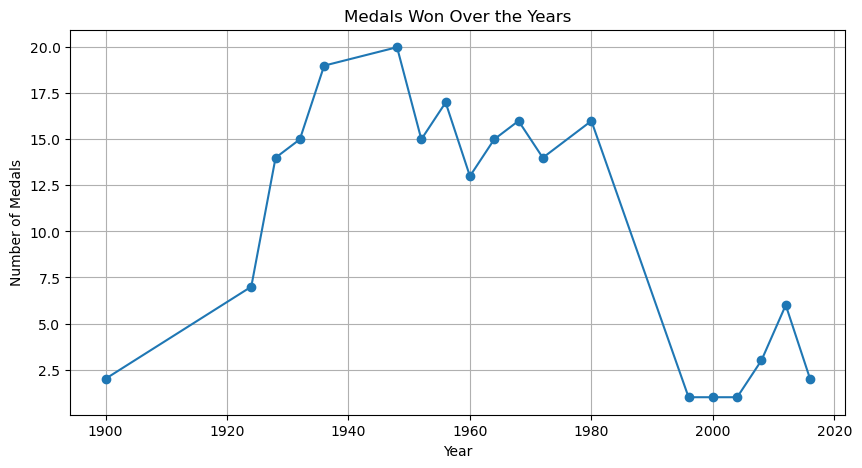

In [31]:
x=input("Enter Country")
country_report(copy,x)

In [33]:
country=input("Enter Country Name")
country_df=copy[copy['region'] == country]

Enter Country Name Russia


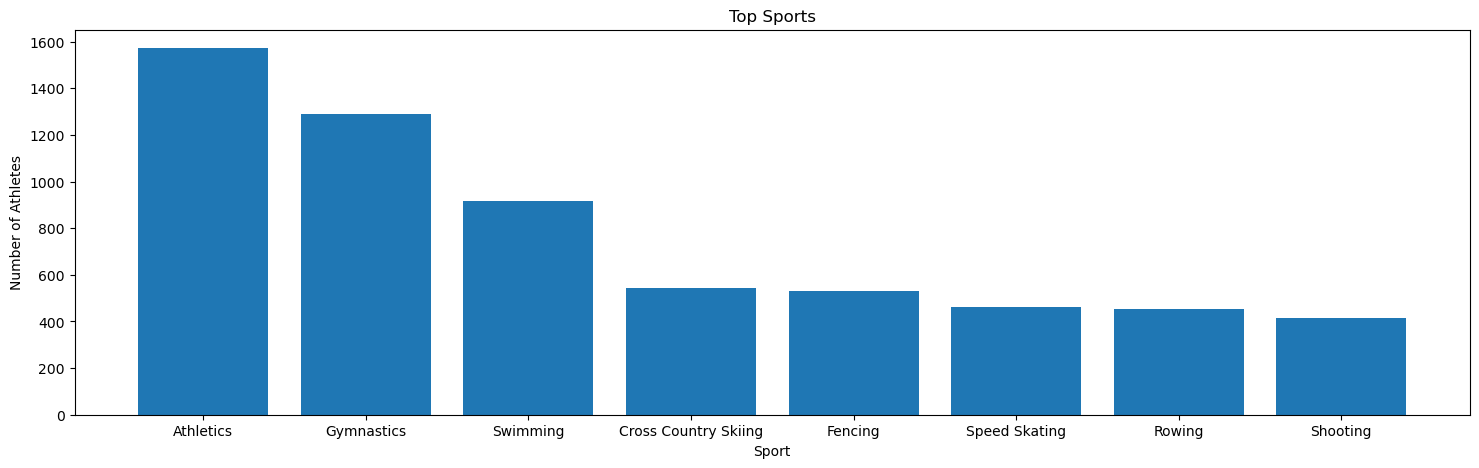

In [34]:
sports = country_df['Sport'].value_counts().head(8)
plt.figure(figsize=(18,5))
plt.bar(sports.index, sports.values)
plt.title("Top Sports")
plt.xlabel("Sport")
plt.ylabel("Number of Athletes")
plt.show()

In [79]:
def plot_top_athletes(df, country):
    country_df = df[df['region'] == country]
    medals = country_df.dropna(subset=['Medal'])
    top10 = medals['Name'].value_counts().head(5)
    plt.figure(figsize=(20,6))
    plt.bar(top10.index, top10.values)
    plt.title(f"Top 10 Medal-Winning Athletes - {country}")
    plt.xlabel("Athlete")
    plt.ylabel("Number of Medals")
    plt.show()

Enter the country India


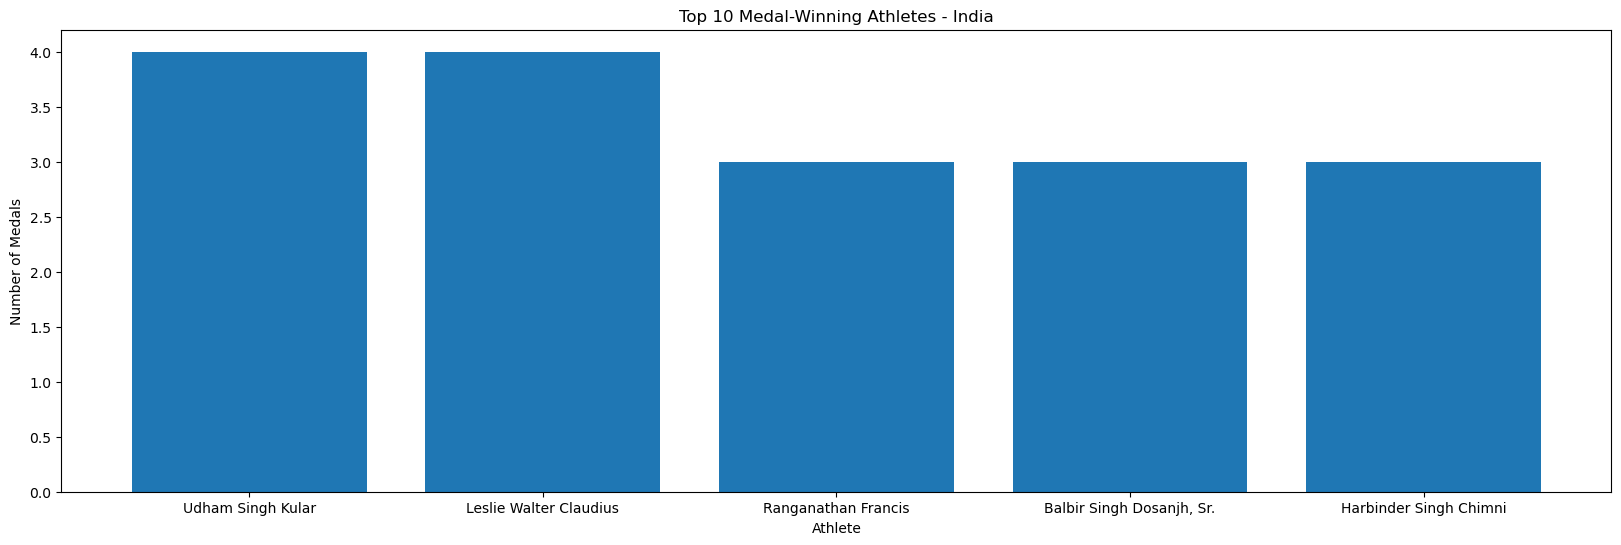

In [80]:
x=input("Enter the country")
plot_top_athletes(copy,x)

In [37]:
def athlete_info(athlete_df):
    print("="*50)
    print("Athlete Information")
    print("="*50)
    print("Name :", athlete_df['Name'].iloc[0])
    print("Country :", athlete_df['region'].iloc[0])
    print("Sport :", athlete_df['Sport'].iloc[0])
    print("Gender :", athlete_df['Sex'].iloc[0])
    print("Olympic Games :", athlete_df['Games'].nunique())

In [38]:
def athlete_medals(athlete_df):
    medals = athlete_df.dropna(subset=['Medal'])
    print("Gold :",(medals['Medal']=="Gold").sum())
    print("Silver :",(medals['Medal']=="Silver").sum())
    print("Bronze :",(medals['Medal']=="Bronze").sum())
    print("Total :",len(medals))

In [39]:
def athlete_report(df, athlete_name):
    athlete = df[df['Name'] == athlete_name]
    if athlete.empty:
        print("Athlete not found.")
        return
    athlete_info(athlete)
    athlete_medals(athlete)
    print("\nOlympic History")
    print(athlete[['Year','City','Sport','Event','Medal']])
    medals = athlete.dropna(subset=['Medal'])
    timeline = medals.groupby('Year')['Medal'].count()
    plt.figure(figsize=(10,5))
    plt.plot(timeline.index,timeline.values,marker='o')
    plt.title(f"Performance Timeline - {athlete_name}")
    plt.xlabel("Year")
    plt.ylabel("Medals")
    plt.grid()
    plt.show()
    medal_count = medals['Medal'].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(medal_count.values,labels=medal_count.index,autopct="%1.1f%%")
    plt.title("Medal Distribution")
    plt.show()

Enter name of Athlete Hossein Reza Zadeh


Athlete Information
Name : Hossein Reza Zadeh
Country : Iran
Sport : Weightlifting
Gender : M
Olympic Games : 2
Gold : 2
Silver : 0
Bronze : 0
Total : 2

Olympic History
        Year    City          Sport                                  Event  \
198575  2000  Sydney  Weightlifting  Weightlifting Men's Super-Heavyweight   
198576  2004  Athina  Weightlifting  Weightlifting Men's Super-Heavyweight   

       Medal  
198575  Gold  
198576  Gold  


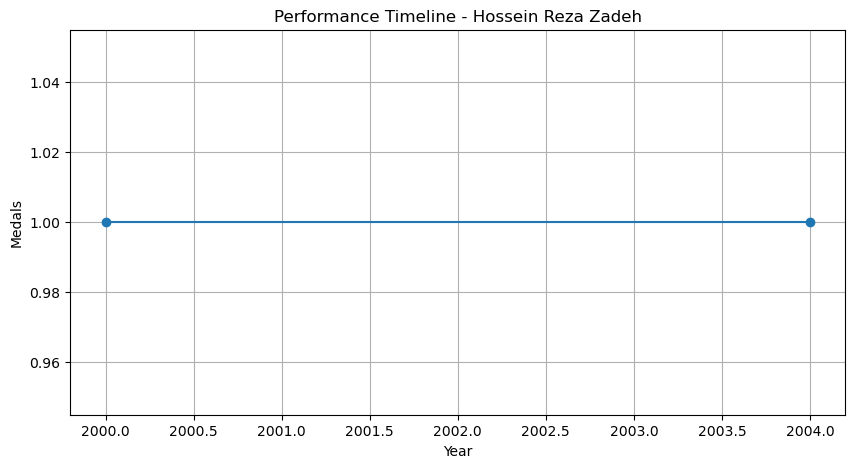

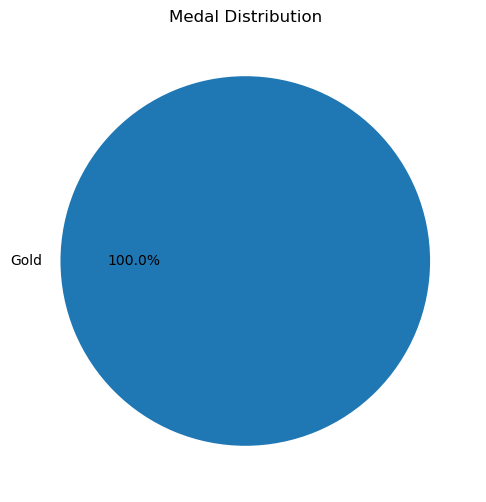

In [40]:
name=input("Enter name of Athlete")
athlete_report(copy, name)

In [41]:
games = copy[['Year', 'Games']].drop_duplicates().sort_values('Year')
games.head()

,Year,Games
3078,1896,1896 Summer
3,1900,1900 Summer
711,1904,1904 Summer
268,1906,1906 Summer
1149,1908,1908 Summer


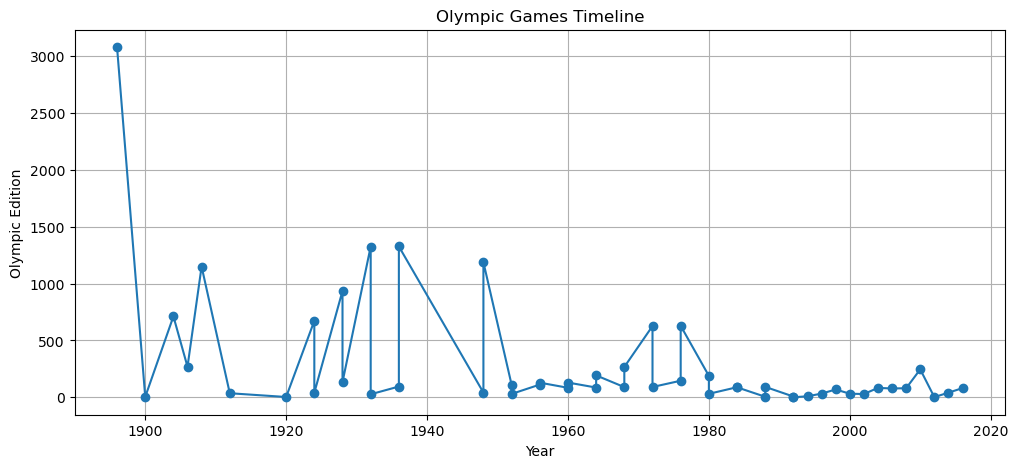

In [42]:
plt.figure(figsize=(12,5))
plt.plot(games['Year'], games['Games'].index + 1, marker='o')
plt.title("Olympic Games Timeline")
plt.xlabel("Year")
plt.ylabel("Olympic Edition")
plt.grid(True)
plt.show()

In [43]:
country_year =copy.groupby('Year')['region'].nunique()
country_year.head()

Year
1896    12
1900    31
1904    14
1906    20
1908    22
Name: region, dtype: int64

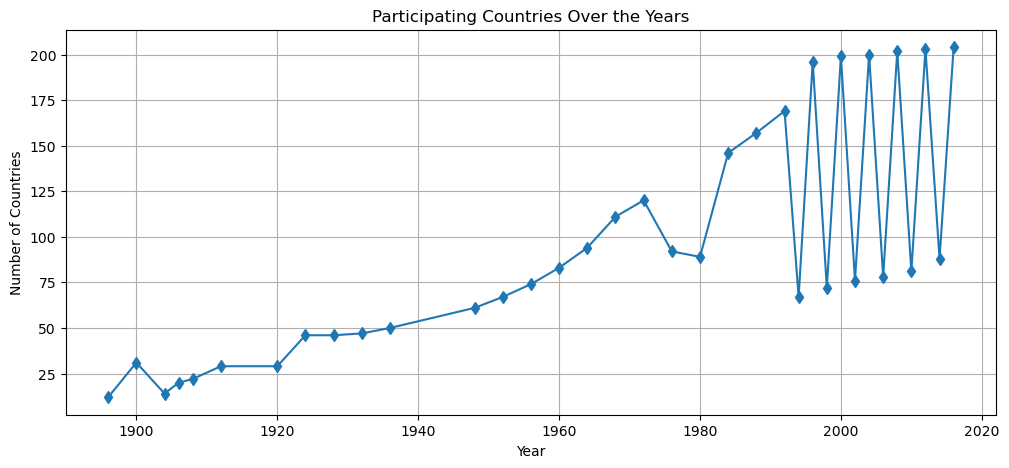

In [44]:
plt.figure(figsize=(12,5))
plt.plot(country_year.index,country_year.values,marker='d')
plt.title("Participating Countries Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.grid()

plt.show()

In [45]:
athlete_year = copy.groupby('Year')['Name'].nunique()
athlete_year.head()

Year
1896     176
1900    1220
1904     650
1906     841
1908    2024
Name: Name, dtype: int64

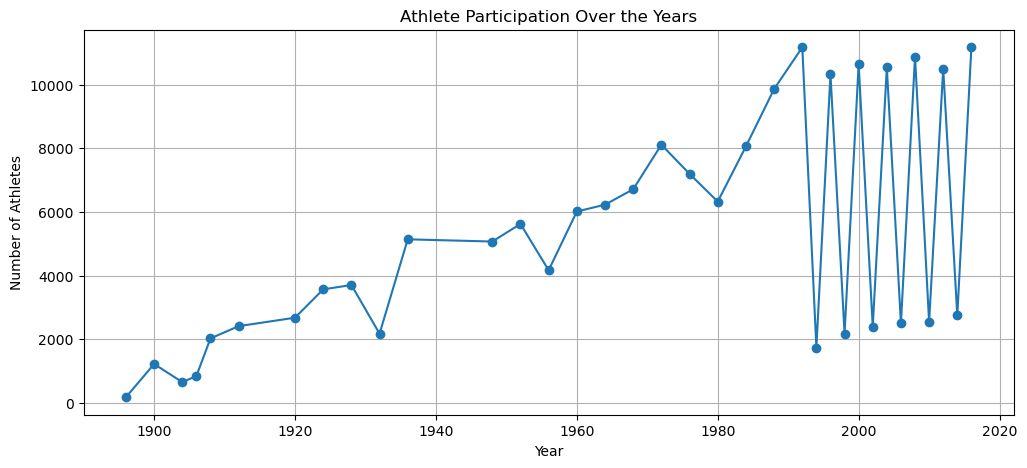

In [46]:
plt.figure(figsize=(12,5))
plt.plot(athlete_year.index,athlete_year.values,marker='o')
plt.title("Athlete Participation Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.grid()
plt.show()

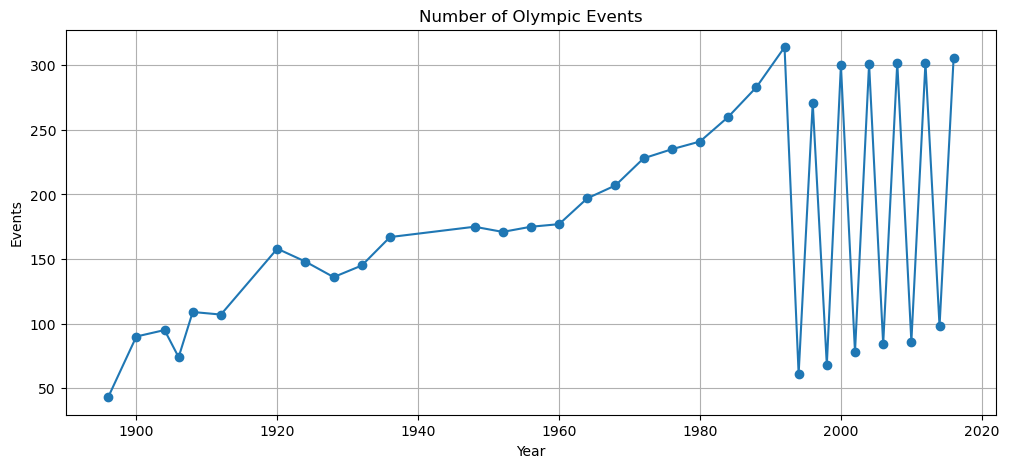

In [47]:
event_year = copy.groupby('Year')['Event'].nunique()
plt.figure(figsize=(12,5))
plt.plot(event_year.index,event_year.values,marker='o')
plt.title("Number of Olympic Events")
plt.xlabel("Year")
plt.ylabel("Events")
plt.grid()
plt.show()

In [48]:
sports = copy['Sport'].value_counts().head(10)
sports

Sport
Athletics               38624
Gymnastics              26707
Swimming                23195
Shooting                11448
Cycling                 10827
Fencing                 10735
Rowing                  10595
Cross Country Skiing     9133
Alpine Skiing            8829
Wrestling                7154
Name: count, dtype: int64

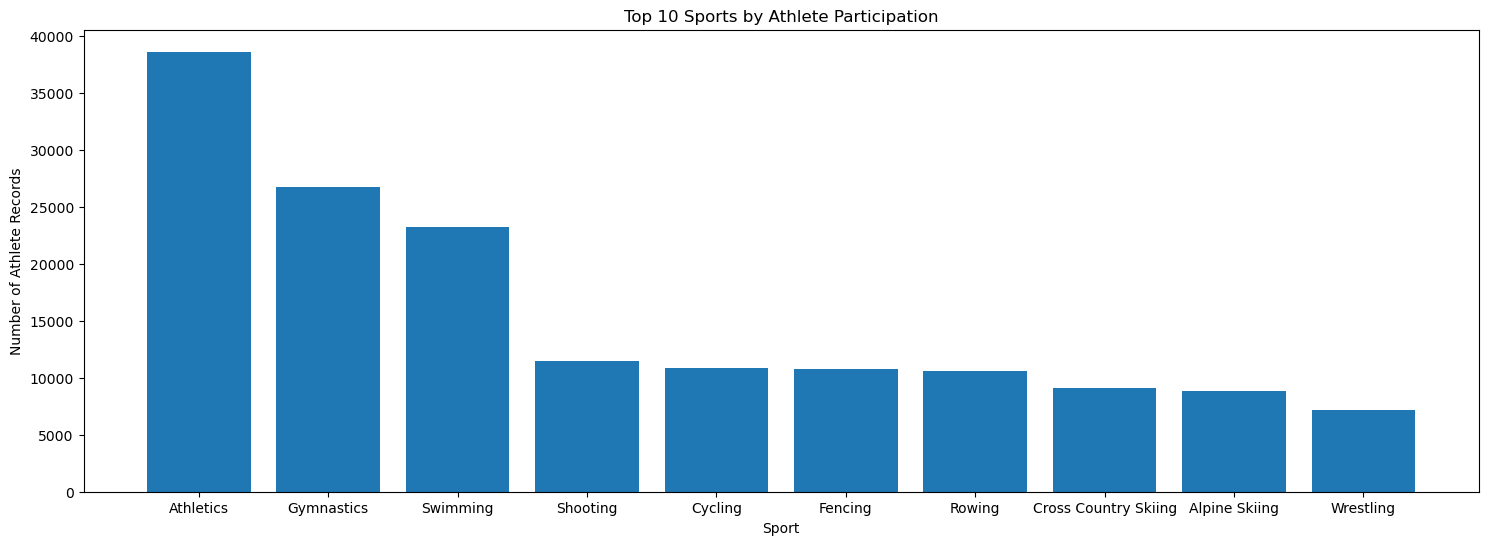

In [49]:
plt.figure(figsize=(18,6))
bars = plt.bar(sports.index,sports.values)
plt.title("Top 10 Sports by Athlete Participation")
plt.xlabel("Sport")
plt.ylabel("Number of Athlete Records")
plt.show()

In [50]:
gender = copy['Sex'].value_counts()
gender

Sex
M    195353
F     74378
Name: count, dtype: int64

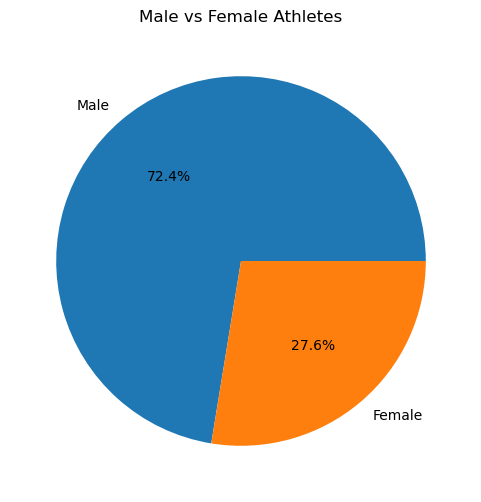

In [51]:
plt.figure(figsize=(6,6))
plt.pie(gender.values,labels=['Male','Female'],autopct='%1.1f%%')
plt.title("Male vs Female Athletes")
plt.show()

In [52]:
cities = copy['City'].value_counts().head(10)
cities

City
London            22297
Athina            15556
Sydney            13821
Atlanta           13780
Rio de Janeiro    13688
Beijing           13602
Barcelona         12977
Seoul             12037
Los Angeles       11919
Munich            10304
Name: count, dtype: int64

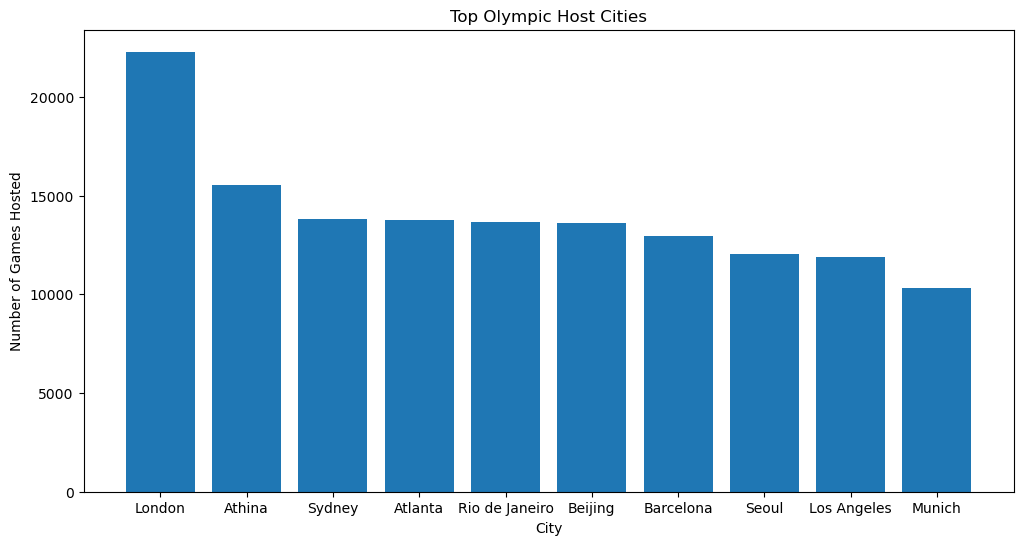

In [53]:
plt.figure(figsize=(12,6))
plt.bar(cities.index,cities.values)
plt.title("Top Olympic Host Cities")
plt.xlabel("City")
plt.ylabel("Number of Games Hosted")
plt.show()

In [54]:
season = copy['Season'].value_counts()
season

Season
Summer    221167
Winter     48564
Name: count, dtype: int64

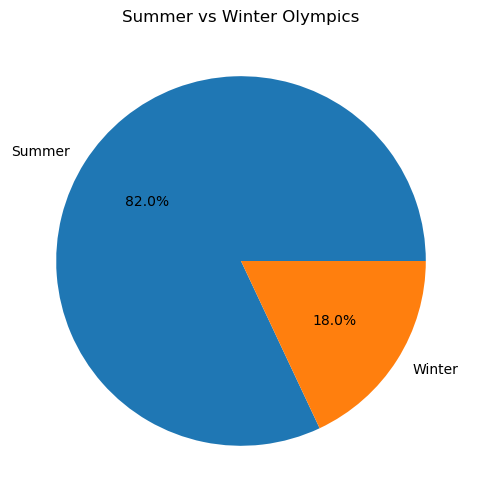

In [55]:
plt.figure(figsize=(6,6))
plt.pie(season.values,labels=season.index,autopct="%1.1f%%")
plt.title("Summer vs Winter Olympics")
plt.show()

In [56]:
medal_df = df.dropna(subset=['Medal'])
sport_medals = medal_df['Sport'].value_counts().head(10)

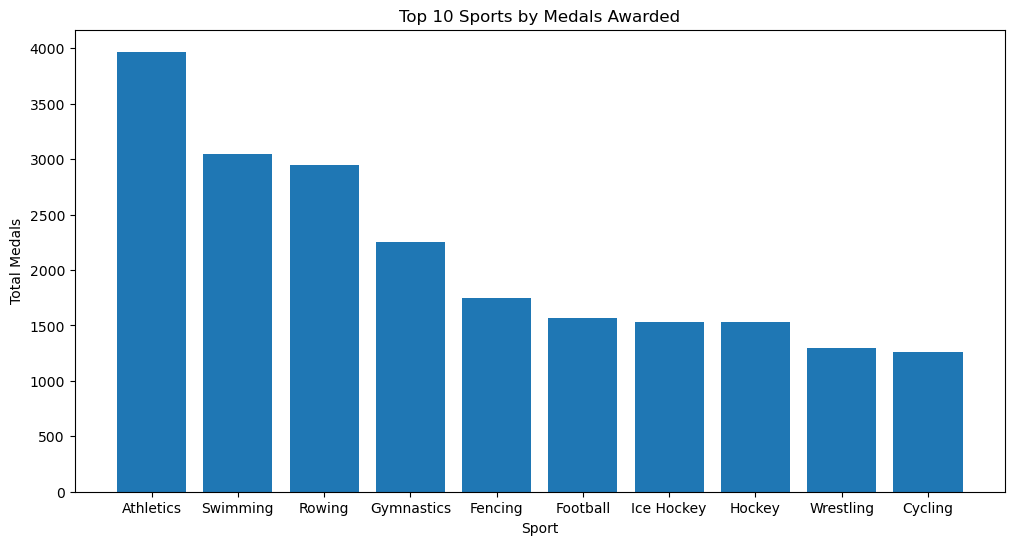

In [57]:
plt.figure(figsize=(12,6))
bars = plt.bar(sport_medals.index,sport_medals.values)
plt.title("Top 10 Sports by Medals Awarded")
plt.xlabel("Sport")
plt.ylabel("Total Medals")
plt.show()

In [58]:
def menu():
    while True:
        print("\n" + "="*45)
        print("OLYMPIC GAMES ANALYZER")
        print("="*45)
        print("1. Overall Dashboard")
        print("2. Medal Tally")
        print("3. Country Analysis")
        print("4. Athlete Analysis")
        print("5. Top Sports")
        print("6. Top Athletes")
        print("7. Exit")
        choice = input("\nEnter your choice: ")
        if choice == "1":
            overall_dashboard(df)
        elif choice == "2":
            medal_menu()
        elif choice == "3":
            country_menu()
        elif choice == "4":
            athlete_menu()
        elif choice == "5":
            top_sports_chart(df)
        elif choice == "6":
            top_athletes_world(df)
        elif choice == "7":
            print("\nThank you for using Olympic Games Analyzer.")
            break
        else:
            print("Invalid Choice!")

In [59]:
def overall_dashboard(df):
    print("\n========== OVERALL DASHBOARD ==========\n")
    print("Olympic Games :", df['Games'].nunique())
    print("Countries     :", df['region'].nunique())
    print("Sports        :", df['Sport'].nunique())
    print("Events        :", df['Event'].nunique())
    print("Athletes      :", df['Name'].nunique())
    medal_df = df.dropna(subset=['Medal'])
    print("Medal Winners :", medal_df['Name'].nunique())

In [60]:
def medal_menu():
    print("\n1. Overall Medal Tally")
    print("2. Year-wise Medal Tally")
    choice = input("Enter choice: ")
    if choice == "1":
        medal_copy = copy.dropna(subset=['Medal'])
        tally = medal_copy.groupby(['region', 'Medal']).size().unstack(fill_value=0)
        tally['Total'] = (tally['Gold'] +tally['Silver'] +tally['Bronze'])
        tally = tally.sort_values(by='Total', ascending=False)
        print(tally)
    elif choice == "2":
        year = int(input("Enter Olympic Year: "))
        print(medal_tally_year(df, year))

In [61]:
def country_menu():
    country = input("Enter Country Name: ")
    country_report(df, country)
    plot_top_athletes(df, country)

In [62]:
def athlete_menu():
    athlete = input("Enter Athlete Name: ")
    athlete_report(df, athlete)

In [63]:
def top_sports_chart(df):
    sports = df['Sport'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    plt.bar(sports.index, sports.values)
    plt.title("Top 10 Sports")
    plt.xlabel("Sport")
    plt.ylabel("Participants")
    plt.show()

In [64]:
def top_athletes_world(df):
    medal_df = df.dropna(subset=['Medal'])
    top = medal_df.groupby('Name').size().sort_values(ascending=False).head(10)
    plt.figure(figsize=(12,6))
    bars = plt.bar(top.index, top.values)
    plt.title("Top 10 Olympic Athletes")
    plt.xlabel("Athlete")
    plt.ylabel("Total Medals")
    plt.show()

In [65]:
menu()


OLYMPIC GAMES ANALYZER
1. Overall Dashboard
2. Medal Tally
3. Country Analysis
4. Athlete Analysis
5. Top Sports
6. Top Athletes
7. Exit



Enter your choice:  1



========== OVERALL DASHBOARD ==========

Olympic Games : 51
Countries     : 205
Sports        : 66
Events        : 765
Athletes      : 134732
Medal Winners : 28202

OLYMPIC GAMES ANALYZER
1. Overall Dashboard
2. Medal Tally
3. Country Analysis
4. Athlete Analysis
5. Top Sports
6. Top Athletes
7. Exit



Enter your choice:  7



Thank you for using Olympic Games Analyzer.


In [66]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [70]:
button = widgets.Button(description='Analyze Country',button_style='success')
output = widgets.Output()

In [78]:
def country_clicked(b):
     output.clear_output()
     with output:
        country = country_dropdown.value
        country_report(copy, country)
        plot_top_athletes(copy,country)
button.on_click(country_clicked)
display(country_dropdown)
display(button)
display(output)

Dropdown(description='Country:', index=15, layout=Layout(width='400px'), options=('Afghanistan', 'Albania', 'A…

Button(button_style='success', description='Analyze Country', style=ButtonStyle())

Output(outputs=({'traceback': ['\x1b----------------------------------------------------------------------…

In [81]:
button3 = widgets.Button(description="Show Medal Tally",button_style="warning")
output3 = widgets.Output()

In [82]:
def medal_clicked(b):
    output3.clear_output()
    with output3:
        if year_dropdown.value == "Overall":
            tally = medal_copy.groupby(['region', 'Medal']).size().unstack(fill_value=0)
            display(tally(copy))
        else:
            display(medal_tally_year(copy,year_dropdown.value))
button3.on_click(medal_clicked)
display(year_dropdown)
display(button3)
display(output3)

Dropdown(description='Year:', index=11, layout=Layout(width='300px'), options=('Overall', 1896, 1900, 1904, 19…

Button(button_style='warning', description='Show Medal Tally', style=ButtonStyle())

Output()